# PHYS 2550 Homework 1: Linear regression from scratch
**Ziqian Yang | Banner ID# B02081699**

This notebook covers (a)-(d) and the 15-point bonus. All regression fitting is
implemented with NumPy; plots and the PDF report use matplotlib. No scikit-learn,
PyTorch, `np.polyfit`, or library regression fitter is used. The normal equation
appears only in the bonus.

Source: I-Cheng Yeh (2018), *Real Estate Valuation*, UCI Machine Learning Repository,
[doi:10.24432/C5J30W](https://doi.org/10.24432/C5J30W).

## (a) Read and inspect the data
`data` is a 414-by-8 numeric array. `data[:, j]` selects every row of column j;
indices begin at 0. `csv.reader` safely reads the column names. Blank numeric cells
are represented as NaN; we inspect them before fitting.

In [1]:
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

csv_path = Path("real_estate.csv")
with csv_path.open(encoding="utf-8-sig", newline="") as f:
    columns = next(csv.reader(f))
data = np.genfromtxt(csv_path, delimiter=",", skip_header=1,
                     encoding="utf-8-sig", filling_values=np.nan)
np.set_printoptions(suppress=True, precision=6)
print("Column names:", columns)
print("First 5 rows:\n", data[:5])
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

descriptions = [
    ("Record identifier (not a predictor)", "none"),
    ("Transaction date, encoded as a decimal year", "year"),
    ("House age", "years"),
    ("Distance to the nearest MRT station", "metres"),
    ("Convenience stores in the walkable living area", "count"),
    ("Latitude", "degrees"),
    ("Longitude", "degrees"),
    ("House price per unit area (target)", "10,000 NTD/ping")
]
for j, (meaning, unit) in enumerate(descriptions):
    v = data[:, j]
    print(f"{columns[j]}: {meaning}; unit={unit}; "
          f"range=[{np.nanmin(v):.6f}, {np.nanmax(v):.6f}]; "
          f"missing={np.isnan(v).sum()}")
assert data.shape == (414, 8), "Check CSV dimensions."
assert np.isfinite(data).all(), "Inspect missing or non-finite data before fitting."

Column names: ['No', 'X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'Y house price of unit area']
First 5 rows:
 [[   1.      2012.917     32.        84.87882   10.        24.98298
   121.54024   37.9    ]
 [   2.      2012.917     19.5      306.5947     9.        24.98034
   121.53951   42.2    ]
 [   3.      2013.583     13.3      561.9845     5.        24.98746
   121.54391   47.3    ]
 [   4.      2013.5       13.3      561.9845     5.        24.98746
   121.54391   54.8    ]
 [   5.      2012.833      5.       390.5684     5.        24.97937
   121.54245   43.1    ]]
Number of rows: 414
Number of columns: 8
No: Record identifier (not a predictor); unit=none; range=[1.000000, 414.000000]; missing=0
X1 transaction date: Transaction date, encoded as a decimal year; unit=year; range=[2012.667000, 2013.583000]; missing=0
X2 house age: House age; unit=years; range=[0.000000, 43.800000]; m

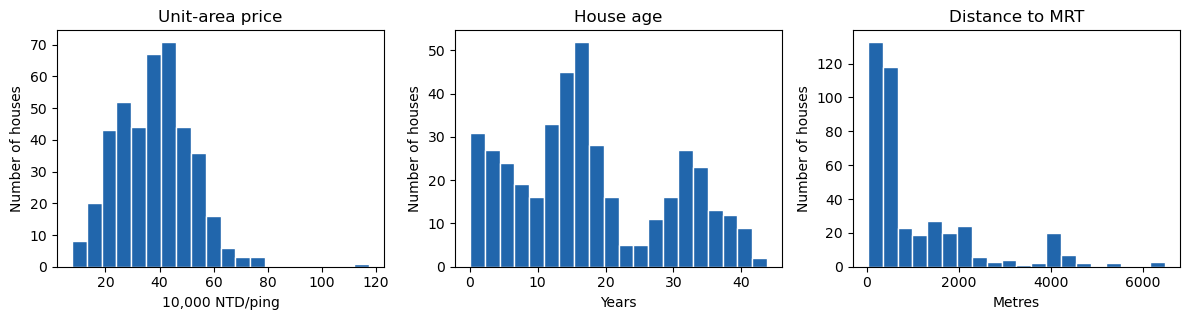

Houses farther than 4,000 m from MRT: 33
Houses with unit-area price above 100: 1
House-age-zero records: 17


In [2]:
price = data[:, 7]
age = data[:, 2]
distance = data[:, 3]

fig_a, axes = plt.subplots(1, 3, figsize=(12, 3.3))
for ax, values, title, unit in zip(
    axes, [price, age, distance],
    ["Unit-area price", "House age", "Distance to MRT"],
    ["10,000 NTD/ping", "Years", "Metres"]
):
    ax.hist(values, bins=20, edgecolor="white", color="#2166ac")
    ax.set(title=title, xlabel=unit, ylabel="Number of houses")
fig_a.tight_layout()
plt.show()

print("Houses farther than 4,000 m from MRT:", np.sum(distance > 4000))
print("Houses with unit-area price above 100:", np.sum(price > 100))
print("House-age-zero records:", np.sum(age == 0))

**Observations.** No missing values were detected in any column. Most unit-area
prices are roughly 20-60 (10,000 NTD/ping); the high value 117.5 is a potential
outlier. House ages are unevenly distributed, with concentrations around 10-20
years and 30-35 years. Age zero can represent a new house, not a missing value.
MRT distance is strongly right-skewed, with most records at short distances and
a small number several kilometres away (maximum 6488.021 m).
Age is at most 43.8 years whereas distance reaches thousands of metres; this scale
difference matters for gradient descent in (c). Extreme values are retained.
These marginal histograms do not establish relationships with price.

## (b) Derive the loss and gradient
Let $x_i$ be house age, $y_i$ the unit-area price, and $n=414$.

$$\hat y_i=w_0+w_1x_i,\qquad
L(w_0,w_1)=\frac1n\sum_{i=1}^n(w_0+w_1x_i-y_i)^2.$$

By the chain rule, with $e_i=w_0+w_1x_i-y_i$:

$$\frac{\partial L}{\partial w_0}
=\frac1n\sum_i 2e_i\frac{\partial e_i}{\partial w_0}
=\frac2n\sum_i e_i,$$
$$\frac{\partial L}{\partial w_1}
=\frac1n\sum_i 2e_i\frac{\partial e_i}{\partial w_1}
=\frac2n\sum_i e_ix_i.$$

Both gradients must use the **same old weights**:
$$w_0\leftarrow w_0-\alpha\frac{\partial L}{\partial w_0},\qquad
w_1\leftarrow w_1-\alpha\frac{\partial L}{\partial w_1}.$$

In [3]:
x = age
y = price
n = len(y)

def fit_one_feature(x, y, learning_rate, epochs):
    w0, w1 = 0.0, 0.0
    losses = [np.mean((w0 + w1*x - y)**2)]  # epoch 0
    weights = [[w0, w1]]
    for epoch in range(epochs):
        error = w0 + w1*x - y
        grad0 = 2*np.mean(error)
        grad1 = 2*np.mean(error*x)
        # Both gradients were computed before either weight changed.
        w0 = w0 - learning_rate*grad0
        w1 = w1 - learning_rate*grad1
        loss = np.mean((w0 + w1*x - y)**2)
        losses.append(loss)
        weights.append([w0, w1])
        # Stop a failed trial before numerical overflow; do not clip the loss.
        if not np.isfinite(loss) or loss > 1e20:
            break
    return np.array([w0, w1]), np.array(losses), np.array(weights)

# A short pilot identifies a useful stable learning rate.
for rate in [0.0001, 0.001, 0.003]:
    trial_w, trial_loss, _ = fit_one_feature(x, y, rate, 1000)
    print(f"Pilot alpha={rate}: updates={len(trial_loss)-1}, "
          f"final MSE={trial_loss[-1]:.6g}")

alpha_b, epochs_b = 0.001, 40000
wb, loss_b, weights_b = fit_one_feature(x, y, alpha_b, epochs_b)
pred_b = wb[0] + wb[1]*x
print("Final [w0, w1]:", wb)
print("Final MSE:", loss_b[-1])
print("Absolute change in weights over the last 1,000 updates:",
      np.max(np.abs(weights_b[-1] - weights_b[-1001])))
for k in [1000, 5000, 10000, 20000, 40000]:
    print(f"epoch={k:5d}: MSE={loss_b[k]:.10f}, weights={weights_b[k]}")

Pilot alpha=0.0001: updates=1000, final MSE=643.341
Pilot alpha=0.001: updates=1000, final MSE=339.812
Pilot alpha=0.003: updates=39, final MSE=1.60927e+20
Final [w0, w1]: [42.434697 -0.251488]
Final MSE: 176.50047403131393
Absolute change in weights over the last 1,000 updates: 2.4524098307665554e-09
epoch= 1000: MSE=339.8119371455, weights=[18.790772  0.694046]
epoch= 5000: MSE=178.0341479456, weights=[40.143419 -0.159859]
epoch=10000: MSE=176.5049576481, weights=[42.31081  -0.246534]
epoch=20000: MSE=176.5004740696, weights=[42.434335 -0.251474]
epoch=40000: MSE=176.5004740313, weights=[42.434697 -0.251488]


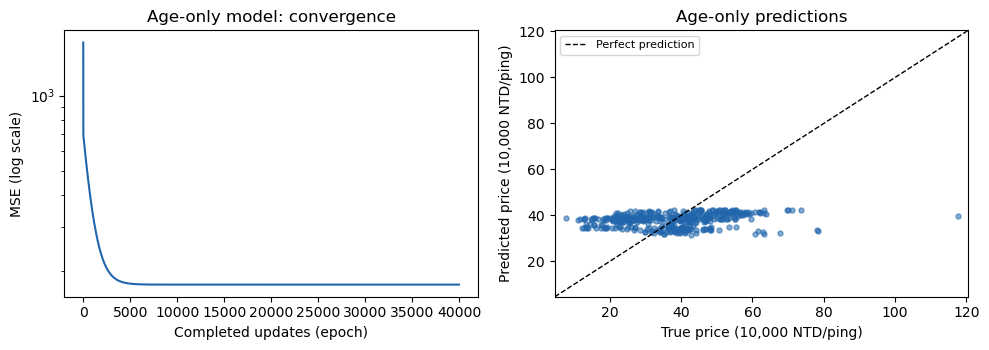

Mean-only baseline MSE: 184.68931783705574
Age-only R-squared: 0.04433848097791182


In [4]:
fig_b, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].semilogy(np.arange(len(loss_b)), loss_b, color="#2166ac")
ax[0].set(xlabel="Completed updates (epoch)", ylabel="MSE (log scale)",
          title="Age-only model: convergence")
ax[1].scatter(y, pred_b, s=13, alpha=0.55, color="#2166ac")
lims = [min(y.min(), pred_b.min())-3, max(y.max(), pred_b.max())+3]
ax[1].plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
ax[1].set(xlim=lims, ylim=lims, xlabel="True price (10,000 NTD/ping)",
          ylabel="Predicted price (10,000 NTD/ping)", title="Age-only predictions")
ax[1].legend(fontsize=8)
fig_b.tight_layout()
plt.show()

baseline_mse = np.mean((y-y.mean())**2)
print("Mean-only baseline MSE:", baseline_mse)
print("Age-only R-squared:", 1-loss_b[-1]/baseline_mse)

**Choice and interpretation.** The pilot at 0.003 diverges, 0.0001 progresses
slowly, and 0.001 is stable and faster. We use 40,000 updates, at which point the
loss has plateaued and the printed final-window weight change is negligible.
An epoch here means one full-batch update using all 414 records.

House age alone is a weak linear predictor: predictions occupy a narrow price
band while actual prices vary widely. The negative slope captures an average
association, but the model particularly underpredicts high prices; the small
in-sample R² confirms that it improves little on predicting the mean.

## (c) More features: vector form and scaling
Use exactly the two required features: house age and MRT distance. No optional
third feature is needed to satisfy the question.

For one house append a constant 1:
$$\mathbf{x}_i=(1,x_{i1},x_{i2})^T,\qquad
\hat y_i=\mathbf{w}^T\mathbf{x}_i.$$
For all houses, the rows of $X$ are $\mathbf{x}_i^T$:
$$X\in\mathbb R^{n\times(p+1)},\quad \mathbf w\in\mathbb R^{p+1},\quad
\hat{\mathbf y}=X\mathbf w.$$
$$L(\mathbf w)=\frac1n(X\mathbf w-\mathbf y)^T(X\mathbf w-\mathbf y),$$
$$\nabla L(\mathbf w)=\frac2n X^T(X\mathbf w-\mathbf y),\qquad
\mathbf w\leftarrow\mathbf w-\alpha\nabla L(\mathbf w).$$

In [5]:
features = data[:, [2, 3]]
X_raw = np.column_stack([np.ones(n), features])

def gradient_descent(X, y, learning_rate, epochs):
    w = np.zeros(X.shape[1])
    history = [np.mean((X@w-y)**2)]
    weight_history = [w.copy()]
    for epoch in range(epochs):
        error = X@w-y
        gradient = (2/len(y))*(X.T@error)
        w = w-learning_rate*gradient
        loss = np.mean((X@w-y)**2)
        history.append(loss)
        weight_history.append(w.copy())
        if not np.isfinite(loss) or loss > 1e20:
            break
    return w, np.array(history), np.array(weight_history)

alpha_c, epochs_c = 0.05, 2000
w_raw_bad, loss_raw_bad, _ = gradient_descent(X_raw, y, alpha_c, epochs_c)
print("Raw-feature trial: alpha =", alpha_c)
print("Updates before stopping:", len(loss_raw_bad)-1)
print("Recorded MSE:", loss_raw_bad)

Raw-feature trial: alpha = 0.05
Updates before stopping: 2
Recorded MSE: [1.627184e+03 2.426628e+13 1.853883e+24]


Standardize **only the feature columns**, before adding the ones column:
$$z_{ij}=\frac{x_{ij}-\mu_j}{s_j},\quad
\mu_j=\frac1n\sum_i x_{ij},\quad
s_j=\sqrt{\frac1n\sum_i(x_{ij}-\mu_j)^2}.$$
We use NumPy's population standard deviation, `ddof=0`. The target stays in its
original units. An intercept column has zero standard deviation, so do not
standardize it. Means/scales use the fitting data; in a future train/test version
they must be learned from the training split only.

Feature means: [  17.71256  1083.885689]
Feature standard deviations: [  11.378717 1260.584387]
Standardized model [intercept, age, distance]: [37.980193 -2.628786 -9.087074]
Final MSE: 93.97976963938086
MSE reduction vs (b), percent: 46.753814597286926
Equivalent original-unit coefficients: [49.885586 -0.231027 -0.007209]


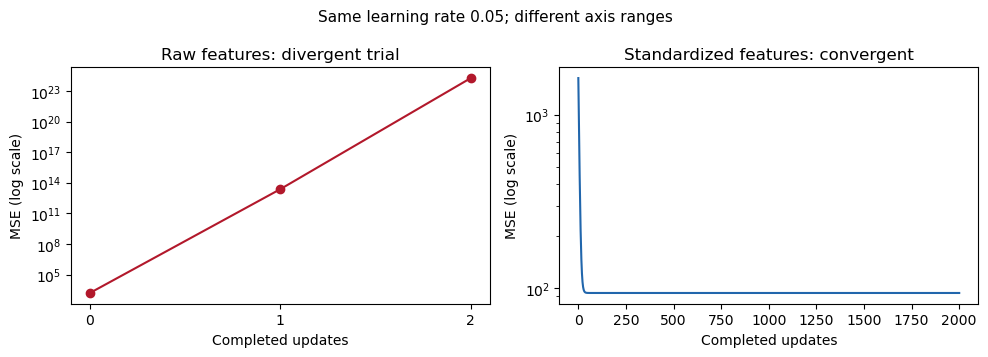

In [6]:
mu = features.mean(axis=0)
sigma = features.std(axis=0, ddof=0)
assert np.all(sigma > 0)
Z = (features-mu)/sigma
X_std = np.column_stack([np.ones(n), Z])
wc, loss_c, weights_c = gradient_descent(X_std, y, alpha_c, epochs_c)
pred_c = X_std@wc

print("Feature means:", mu)
print("Feature standard deviations:", sigma)
print("Standardized model [intercept, age, distance]:", wc)
print("Final MSE:", loss_c[-1])
print("MSE reduction vs (b), percent:", 100*(loss_b[-1]-loss_c[-1])/loss_b[-1])

# Convert coefficients back to the original feature units.
raw_slopes = wc[1:]/sigma
raw_intercept = wc[0]-mu@raw_slopes
wc_original = np.r_[raw_intercept, raw_slopes]
print("Equivalent original-unit coefficients:", wc_original)
assert np.allclose(pred_c, X_raw@wc_original)

fig_c, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].semilogy(np.arange(len(loss_raw_bad)), loss_raw_bad, "o-", color="#b2182b")
ax[0].set(title="Raw features: divergent trial", xlabel="Completed updates",
          ylabel="MSE (log scale)")
ax[0].set_xticks(np.arange(len(loss_raw_bad)))
ax[1].semilogy(np.arange(len(loss_c)), loss_c, color="#2166ac")
ax[1].set(title="Standardized features: convergent", xlabel="Completed updates",
          ylabel="MSE (log scale)")
fig_c.suptitle("Same learning rate 0.05; different axis ranges", fontsize=11)
fig_c.tight_layout()
plt.show()

In [7]:
# Diagnostic: scaling changes the allowable step size, not whether a fit exists.
H_raw = (2/n)*(X_raw.T@X_raw)
H_std = (2/n)*(X_std.T@X_std)
limit_raw = 2/np.linalg.eigvalsh(H_raw).max()
limit_std = 2/np.linalg.eigvalsh(H_std).max()
print("Raw-feature stability bound alpha <", limit_raw)
print("Standardized stability bound alpha <", limit_std)

w_raw_slow, loss_raw_slow, _ = gradient_descent(X_raw, y, 1e-7, epochs_c)
print("Raw but stable: alpha=1e-7, updates=2000, final MSE=", loss_raw_slow[-1])

Raw-feature stability bound alpha < 3.6179186538633623e-07
Standardized stability bound alpha < 0.9750180415596325
Raw but stable: alpha=1e-7, updates=2000, final MSE= 1177.5413339225877


**Why the raw trial fails.** For this quadratic loss the Hessian is
$H=2X^TX/n$. Full-batch gradient descent converges for
$0<\alpha<2/\lambda_{\max}(H)$ when $X$ has full column rank.
The large numerical scale of distance makes the raw bound about $3.62\times10^{-7}$;
0.05 overshoots and the loss explodes. The divergent trial is explicitly stopped
above $10^{20}$ rather than allowed to overflow.

After standardization the bound is about 0.975, so 0.05 is conservative and stable.
The stable raw control at $10^{-7}$ demonstrates that standardization is not a
mathematical requirement: tiny steps can work but make very slow progress.
Standardization preserves the family of linear predictions and the achievable
minimum MSE. **Adding distance**, not scaling by itself, explains the lower
converged MSE relative to (b).

## (d) Compare models and discuss limitations
The comparison uses identical observations and target units. R² is relative to
the mean-only baseline; it is not a percentage of correct predictions.

Model               MSE          RMSE        R-squared
Mean only           184.689318   13.590045    0.000000
Age only            176.500474   13.285348    0.044338
Age + distance       93.979770    9.694316    0.491147


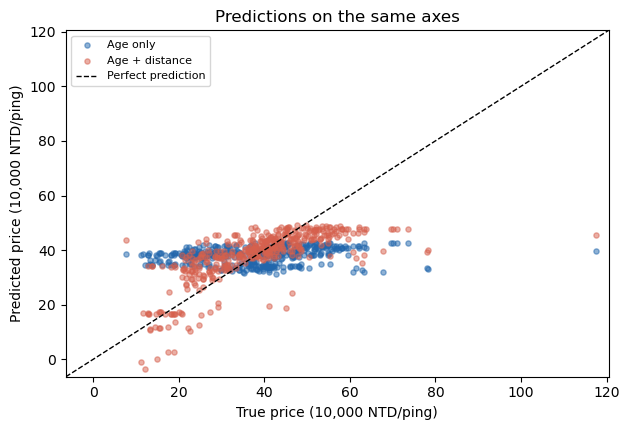

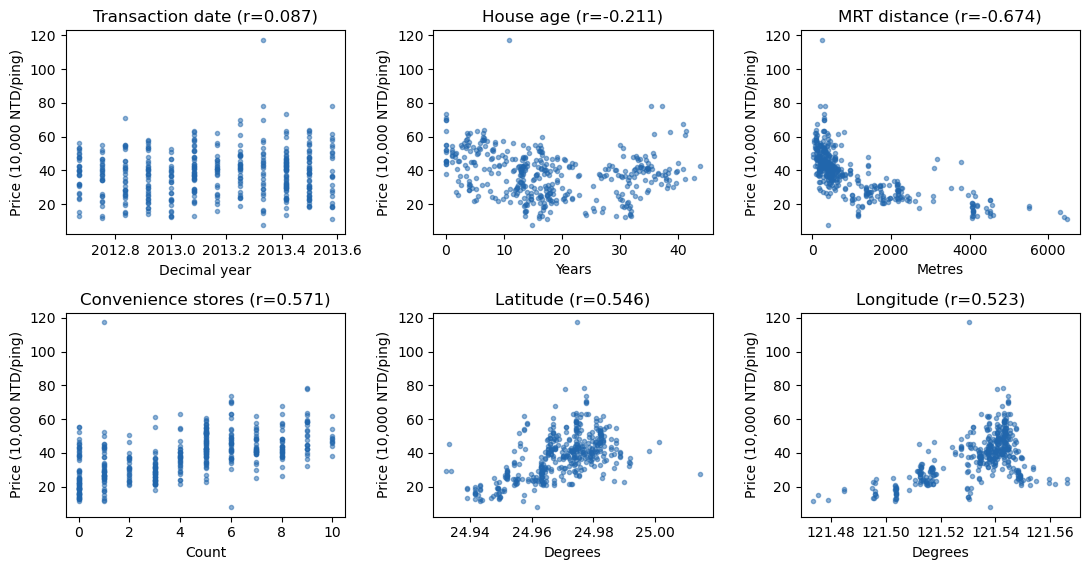

In [8]:
print("Model               MSE          RMSE        R-squared")
for name, pred in [("Mean only", np.full(n, y.mean())),
                   ("Age only", pred_b), ("Age + distance", pred_c)]:
    mse = np.mean((pred-y)**2)
    print(f"{name:18s} {mse:11.6f} {np.sqrt(mse):11.6f} {1-mse/baseline_mse:11.6f}")

fig_d, ax = plt.subplots(figsize=(6.4, 4.4))
ax.scatter(y, pred_b, s=14, alpha=0.5, label="Age only", color="#2166ac")
ax.scatter(y, pred_c, s=14, alpha=0.5, label="Age + distance", color="#d6604d")
lo = min(y.min(), pred_b.min(), pred_c.min())-3
hi = max(y.max(), pred_b.max(), pred_c.max())+3
ax.plot([lo,hi], [lo,hi], "k--", linewidth=1, label="Perfect prediction")
ax.set(xlim=(lo,hi), ylim=(lo,hi), xlabel="True price (10,000 NTD/ping)",
       ylabel="Predicted price (10,000 NTD/ping)", title="Predictions on the same axes")
ax.legend(fontsize=8)
fig_d.tight_layout()
plt.show()

feature_names = ["Transaction date", "House age", "MRT distance",
                 "Convenience stores", "Latitude", "Longitude"]
feature_units = ["Decimal year", "Years", "Metres", "Count", "Degrees", "Degrees"]
correlations = np.array([np.corrcoef(data[:, j], y)[0, 1] for j in range(1, 7)])
fig_features, axes = plt.subplots(2, 3, figsize=(11, 5.8))
for j, ax in enumerate(axes.flat):
    ax.scatter(data[:, j+1], y, s=9, alpha=0.5, color="#2166ac")
    ax.set(title=f"{feature_names[j]} (r={correlations[j]:.3f})",
           xlabel=feature_units[j], ylabel="Price (10,000 NTD/ping)")
    ax.ticklabel_format(axis="x", style="plain", useOffset=False)
fig_features.tight_layout()
plt.show()

**Discussion.** Adding MRT distance substantially lowers in-sample MSE and spreads
predictions closer to the identity line. Distance shows a stronger negative
association with price than age. Store count and geographic coordinates also
show associations in the exploratory plots; age is weakly negative and date has
little marginal linear association in this sample. This does not prove that date
contains no information or that the other features each add independent predictive
value. The row identifier is not a meaningful housing feature.

Raw feature scale and learning rate initially limited optimization. After scaling
and enough updates, the remaining error is mostly a modeling/data issue rather
than incomplete convergence. Extreme prices receive large weight under squared
loss; outliers, missing housing characteristics, and nonlinear/location effects
limit a simple linear fit. Some low-end predictions may even be negative because
the model is unconstrained; predictions are not clipped.

A second version would reserve a test set, fit scaling only on training data,
use validation to compare more features and nonlinear transformations (for example
log distance), inspect residuals and influential observations, and consider a
robust loss. Large values should be investigated rather than automatically deleted.

## Bonus: normal equation and a quantitative convergence test
At the minimum the gradient is zero:
$$X^T(X\mathbf w_* - \mathbf y)=0
\Longrightarrow (X^TX)\mathbf w_*=X^T\mathbf y.$$
With full column rank,
$$\mathbf w_*=(X^TX)^{-1}X^T\mathbf y.$$
We use `np.linalg.solve(X.T @ X, X.T @ y)` to solve this same equation rather than
explicitly form an inverse. It is an algebraic linear-system solver, allowed here
for the bonus. Both methods use **the same standardized design matrix**.

Define the tolerances before checking the histories:
$$E_w(k)=\frac{\|\mathbf w_k-\mathbf w_*\|_2}{\max(1,\|\mathbf w_*\|_2)}<10^{-6},$$
$$E_L(k)=\frac{|L(\mathbf w_k)-L(\mathbf w_*)|}{\max(1,L(\mathbf w_*))}<10^{-8}.$$
We also report maximum absolute prediction disagreement, in original price units.
The first epoch meeting **both** thresholds answers how many updates were needed.
Weight histories include epoch 0, so array index k equals completed updates k.

Normal-equation weights: [37.980193 -2.628786 -9.087074]
Normal-equation MSE: 93.97976963938088
Final GD weights: [37.980193 -2.628786 -9.087074]
Final GD MSE: 93.97976963938086
First epoch meeting BOTH criteria: 132
Epoch | relative weight error | relative loss error | max prediction gap
  131 | 1.0090476075e-06 | 1.6594290709e-11 | 4.7200499367e-05
  132 | 9.0816244222e-07 | 1.3441674874e-11 | 4.2533731197e-05
 2000 | 7.3914780035e-16 | 1.5121184878e-16 | 4.2632564146e-14


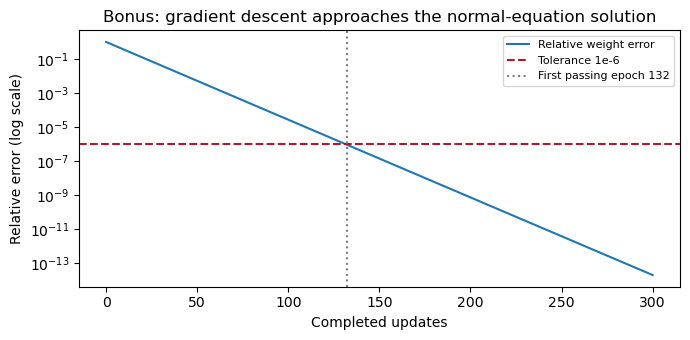

In [9]:
weight_tolerance = 1e-6
loss_tolerance = 1e-8
assert np.linalg.matrix_rank(X_std) == X_std.shape[1]
w_star = np.linalg.solve(X_std.T@X_std, X_std.T@y)
pred_star = X_std@w_star
loss_star = np.mean((pred_star-y)**2)

relative_weight_error = np.linalg.norm(weights_c-w_star, axis=1)/max(1.0, np.linalg.norm(w_star))
relative_loss_error = np.abs(loss_c-loss_star)/max(1.0, loss_star)
hits = np.flatnonzero((relative_weight_error < weight_tolerance) &
                      (relative_loss_error < loss_tolerance))
first_epoch = int(hits[0]) if len(hits) else None
print("Normal-equation weights:", w_star)
print("Normal-equation MSE:", loss_star)
print("Final GD weights:", wc)
print("Final GD MSE:", loss_c[-1])
print("First epoch meeting BOTH criteria:", first_epoch)
print("Epoch | relative weight error | relative loss error | max prediction gap")
if first_epoch is not None:
    for k in [max(0, first_epoch-1), first_epoch, epochs_c]:
        gap = np.max(np.abs(X_std@weights_c[k]-pred_star))
        print(f"{k:5d} | {relative_weight_error[k]:.10e} | "
              f"{relative_loss_error[k]:.10e} | {gap:.10e}")
else:
    print("Investigate learning rate, epochs, scaling, rank, and gradient implementation.")

fig_bonus, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(np.maximum(relative_weight_error[:301], 1e-17), label="Relative weight error")
ax.axhline(weight_tolerance, color="#b2182b", linestyle="--", label="Tolerance 1e-6")
if first_epoch is not None:
    ax.axvline(first_epoch, color="gray", linestyle=":", label=f"First passing epoch {first_epoch}")
ax.set(xlabel="Completed updates", ylabel="Relative error (log scale)",
       title="Bonus: gradient descent approaches the normal-equation solution")
ax.legend(fontsize=8)
fig_bonus.tight_layout()
plt.show()

**Interpretation.** Gradient descent reaches the stated tolerances. The update
count depends on initialization (zeros), learning rate (0.05), chosen features,
standard deviation convention, and tolerance; it is not a universal constant.
Final differences are near floating-point precision. A visually flat loss alone
would not establish agreement in weights; that is why both criteria are checked.

## Generate the short English report

In [ ]:
NOTEBOOK_URL = "https://github.com/1803488264a-cmyk/phys2550-hw1/blob/main/hw1_complete.ipynb"
AUTHOR = "Ziqian Yang | Banner ID# B02081699"

CONVERSION_NOTE = (
    "I converted the XLSX file to CSV using Excel's Save As option."
)

from matplotlib.backends.backend_pdf import PdfPages
import io
import textwrap

def report_page(title, page_number):
    fig = plt.figure(figsize=(8.27, 11.69), facecolor="white")
    fig.text(0.075, 0.955, "PHYS 2550  /  HOMEWORK 1", fontsize=9, color="#2166ac")
    fig.text(0.075, 0.919, title, fontsize=19, weight="bold", color="#17324d")
    fig.text(0.075, 0.033, AUTHOR + "  |  Linear regression from scratch", fontsize=8, color="#666666")
    fig.text(0.925, 0.033, str(page_number), fontsize=8, color="#666666", ha="right")
    return fig

def paragraph(fig, y_pos, text, fontsize=9.3, width=105):
    lines = []
    for part in text.split("\n"):
        lines.extend(textwrap.wrap(part, width=width) if part else [""])
    fig.text(0.075, y_pos, "\n".join(lines), va="top", fontsize=fontsize,
             linespacing=1.45, color="#222222")
    return y_pos - len(lines)*fontsize*1.45/(11.69*72)

def equation(fig, y_pos, text, fontsize=12):
    fig.text(0.085, y_pos, text, fontsize=fontsize, va="top", color="#17324d")

def report_table(fig, rect, headers, rows, widths=None, fontsize=8.3):
    ax = fig.add_axes(rect)
    ax.axis("off")
    table = ax.table(cellText=rows, colLabels=headers, colWidths=widths,
                     cellLoc="left", colLoc="left", bbox=[0,0,1,1])
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor("#d6e0e8")
        cell.set_linewidth(0.5)
        if r == 0:
            cell.set_facecolor("#17324d")
            cell.set_text_props(color="white", weight="bold")
        elif r % 2:
            cell.set_facecolor("#eff4f8")
    return table

def place_chart(fig, source_fig, rect):
    buf = io.BytesIO()
    source_fig.savefig(buf, format="png", dpi=180, bbox_inches="tight", facecolor="white")
    buf.seek(0)
    ax = fig.add_axes(rect)
    ax.imshow(plt.imread(buf))
    ax.axis("off")

report_path = Path("hw1_report.pdf")
with PdfPages(report_path) as pdf:
    pdf.infodict()["Title"] = "Homework 1 - Linear regression from scratch"
    pdf.infodict()["Author"] = AUTHOR

    # Page 1: data and exploratory analysis.
    p = report_page("(a) Data and exploratory analysis", 1)
    paragraph(p, 0.883, "Notebook: " + NOTEBOOK_URL.strip(), fontsize=8.5, width=105)
    paragraph(p, 0.848, CONVERSION_NOTE + " The CSV contains 414 records and 8 columns. "
              "The notebook prints the first five rows and all column ranges. "
              "All 414 records are retained; every reported metric is in-sample.")
    data_rows = []
    short_names = ["No: record identifier", "X1: transaction date", "X2: house age",
                   "X3: nearest MRT distance", "X4: convenience stores", "X5: latitude",
                   "X6: longitude", "Y: price per unit area"]
    units = ["None (ID)", "Decimal year", "Years", "Metres", "Count", "Degrees", "Degrees", "10,000 NTD/ping"]
    for j in range(8):
        places = 3 if j == 1 else (5 if j in [5,6] else 4)
        data_rows.append([short_names[j], units[j],
                          f"{data[:,j].min():.{places}f} - {data[:,j].max():.{places}f}"])
    report_table(p, [0.075,0.535,0.85,0.23], ["Column / meaning", "Unit", "Observed range"],
                 data_rows, widths=[.4,.23,.37], fontsize=8)
    place_chart(p, fig_a, [0.055,0.300,0.89,0.225])
    paragraph(
        p, 0.285,
        "No missing values were found. Most prices are around 20-60, "
        "with one much higher price at 117.5. "
        "There are relatively few houses aged about 22-28 years. "
        "The MRT-distance histogram shows more houses around 4,000-4,300 metres "
        "than in nearby bins. MRT distances reach thousands of metres, "
        "while house ages are only tens of years.")
    paragraph(p, 0.14,
        "Source: Yeh, I. (2018), Real Estate Valuation, UCI Machine Learning Repository. "
        "https://doi.org/10.24432/C5J30W. Data are from Sindian District, New Taipei City. "
        "One ping is approximately 3.3 square metres; the target is a unit-area price, not total price.",
        fontsize=8.3, width=113)
    pdf.savefig(p); plt.close(p)

    # Page 2: the required scalar derivation and fit.
    p = report_page("(b) Age-only linear regression", 2)
    paragraph(p, 0.878, "Let x be house age, y the unit-area price, and n=414. "
              "Use mean squared error without a factor of 1/2:")
    equation(p, 0.833, r"$\hat y_i=w_0+w_1x_i,\quad e_i=w_0+w_1x_i-y_i,\quad L=\frac{1}{n}\sum_i e_i^2$")
    equation(p, 0.782, r"$\frac{\partial L}{\partial w_0}=\frac{1}{n}\sum_i2e_i\frac{\partial e_i}{\partial w_0}=\frac{2}{n}\sum_i e_i$")
    equation(p, 0.727, r"$\frac{\partial L}{\partial w_1}=\frac{1}{n}\sum_i2e_i\frac{\partial e_i}{\partial w_1}=\frac{2}{n}\sum_i e_ix_i$")
    equation(p, 0.675, r"$w_0\leftarrow w_0-\alpha\,\partial L/\partial w_0,\quad w_1\leftarrow w_1-\alpha\,\partial L/\partial w_1$")
    paragraph(p, 0.628,
        "Both gradients are computed using the same old weights. Initialization is (0,0). "
        "In a 1,000-update pilot, alpha=0.003 diverged, 0.0001 progressed slowly, and 0.001 "
        "was stable and faster. We therefore used alpha=0.001 and 40,000 full-batch updates. "
        "The loss plateau and negligible final-window weight change support this duration.")
    report_table(p, [0.075,0.471,0.85,0.065], ["w0", "w1 (per year)", "Final MSE"],
                 [[f"{wb[0]:.8f}",f"{wb[1]:.8f}",f"{loss_b[-1]:.8f}"]])
    place_chart(p, fig_b, [0.05,0.211,0.90,0.25])
    paragraph(p, 0.19,
        "House age alone is not a good linear predictor: predictions lie in a narrow band while "
        "true prices vary widely, and high prices are especially underpredicted. "
        "MSE is in squared target units; predictions are in 10,000 NTD/ping.")
    pdf.savefig(p); plt.close(p)

    # Page 3: the multivariate gradient and controlled scaling experiment.
    p = report_page("(c) Two features and standardization", 3)
    paragraph(p, 0.878, "Use house age and MRT distance. Append a constant 1 to each feature vector; "
              "the design matrix X has one row per house. The implementation handles any number of columns.")
    equation(p, 0.825, r"$\mathbf{x}_i=(1,x_{i1},x_{i2})^T,\quad \hat y_i=\mathbf{w}^T\mathbf{x}_i,\quad\hat{\mathbf{y}}=X\mathbf{w}$")
    equation(p, 0.782, r"$L=\frac{1}{n}\|X\mathbf{w}-\mathbf{y}\|_2^2,\quad\nabla L=\frac{2}{n}X^T(X\mathbf{w}-\mathbf{y})$")
    equation(p, 0.74, r"$\mathbf{w}\leftarrow\mathbf{w}-\alpha\nabla L,\qquad z_{ij}=(x_{ij}-\mu_j)/s_j$")
    paragraph(p, 0.694,
        "Only the two features are standardized (population standard deviation, ddof=0); "
        "the constant column and target are not. Both trials start at zero and use alpha=0.05, "
        f"with a 2,000-update budget. The raw trial stops after {len(loss_raw_bad)-1} updates "
        "when MSE exceeds 1e20; its recorded values are plotted without clipping.")
    report_table(p, [0.075,0.555,0.85,0.078], ["Feature", "Mean", "Standard deviation"],
                 [["Age",f"{mu[0]:.8f}",f"{sigma[0]:.8f}"],
                  ["MRT distance",f"{mu[1]:.8f}",f"{sigma[1]:.8f}"]])
    place_chart(p, fig_c, [0.05,0.311,0.90,0.235])
    paragraph(p, 0.30,
        f"Standardized coefficients [intercept, age, distance] = [{wc[0]:.8f}, {wc[1]:.8f}, {wc[2]:.8f}]. "
        f"MSE={loss_c[-1]:.8f}, a {100*(loss_b[-1]-loss_c[-1])/loss_b[-1]:.2f}% decrease from (b). "
        f"In original units the equivalent coefficients are [{wc_original[0]:.8f}, "
        f"{wc_original[1]:.8f}, {wc_original[2]:.8f}].")
    paragraph(p, 0.206,
        "With raw features, the loss increased rapidly, indicating divergence. "
        "MRT distance reaches thousands of metres, while house age is measured in tens of years. "
        "The learning rate of 0.05 was too large for this unscaled problem. "
        "Standardization improved the scaling, allowing the same learning rate to converge. "
        "For H=2X^T X/n, the stability bound is 0<alpha<2/lambda_max(H): "
        f"{limit_raw:.3e} before scaling and {limit_std:.6f} afterward. "
        "Scaling improves optimization; adding distance explains the lower converged loss "
        "compared with (b).",
        fontsize=9, width=109)
    pdf.savefig(p); plt.close(p)

    # Page 4: model comparison and the short discussion.
    p = report_page("(d) What the models tell us", 4)
    metric_rows=[]
    for label, prediction in [("Mean only",np.full(n,y.mean())),("Age only",pred_b),("Age + MRT distance",pred_c)]:
        mse = np.mean((prediction-y)**2)
        metric_rows.append([label,f"{mse:.6f}",f"{np.sqrt(mse):.6f}",f"{1-mse/baseline_mse:.6f}"])
    report_table(p,[0.075,0.774,0.85,0.102],["Model", "MSE", "RMSE", "R-squared"],
                 metric_rows,widths=[.34,.22,.22,.22])
    place_chart(p, fig_d, [0.15,0.447,0.70,0.315])
    report_table(p,[0.075,0.338,0.85,0.090],["Feature", "Pearson r", "Feature", "Pearson r"],
        [[feature_names[i],f"{correlations[i]:.3f}",feature_names[i+3],f"{correlations[i+3]:.3f}"] for i in range(3)],
        widths=[.31,.19,.31,.19],fontsize=8.4)
    paragraph(p, 0.321,
        "Adding distance substantially lowers the error and brings predictions closer to the "
        "identity line. MRT distance, the number of convenience stores, latitude, and longitude "
        "show clear associations with price. House age shows a weaker association, while "
        "transaction date shows little linear association. The record ID is not used as a predictor.")
    paragraph(p,0.209,
        "Feature scale and learning rate initially limited optimization. After scaling and convergence, "
        "extreme prices, omitted housing characteristics and nonlinear/location effects limit the linear "
        "model. Squared loss is sensitive to large residuals. "
        "A second version would reserve a test set, fit scaling on training data only, use validation "
        "to compare added features and transformations such as log distance, inspect influential "
        "observations and residuals, and consider a robust loss. ")
    pdf.savefig(p); plt.close(p)

    # Page 5: Bonus
    p = report_page("Bonus: comparison with the normal equation", 5)

    # Compare final coefficients.
    paragraph(
        p, 0.875,
        "Both methods use the standardized features from (c)."
    )

    report_table(
        p,
        [0.075, 0.750, 0.85, 0.090],
        ["Method", "Intercept", "Age coefficient", "Distance coefficient"],
        [
            ["Gradient descent", *[f"{v:.8f}" for v in wc]],
            ["Normal equation", *[f"{v:.8f}" for v in w_star]]
        ],
        widths=[0.28, 0.24, 0.24, 0.24],
        fontsize=8
    )

    paragraph(
        p, 0.735,
        f"Gradient descent MSE: {loss_c[-1]:.10f}. "
        f"Normal-equation MSE: {loss_star:.10f}."
    )

    # Define "close enough."
    paragraph(
        p, 0.685,
        "Define 'close enough' by requiring both relative errors below "
        "the following thresholds, where k is the number of completed updates:"
    )

    equation(
        p, 0.625,
        r"$E_w(k)=\frac{\|\mathbf{w}_k-\mathbf{w}_*\|_2}"
        r"{\max(1,\|\mathbf{w}_*\|_2)}<10^{-6}$"
    )

    equation(
        p, 0.565,
        r"$E_L(k)=\frac{|L(\mathbf{w}_k)-L(\mathbf{w}_*)|}"
        r"{\max(1,L(\mathbf{w}_*))}<10^{-8}$"
    )

    # Show only the first passing epoch and the preceding epoch.
    if first_epoch is not None:
        bonus_rows = []

        for k in sorted(set([max(0, first_epoch - 1), first_epoch])):
            bonus_rows.append([
                str(k),
                f"{relative_weight_error[k]:.4e}",
                f"{relative_loss_error[k]:.4e}"
            ])

        report_table(
            p,
            [0.075, 0.410, 0.85, 0.090],
            ["Epoch", "Relative weight error", "Relative loss error"],
            bonus_rows,
            widths=[0.16, 0.42, 0.42],
            fontsize=8.3
        )

    place_chart(
        p,
        fig_bonus,
        [0.075, 0.160, 0.85, 0.235]
    )

    if first_epoch is not None:
        paragraph(
            p, 0.145,
            f"Using zero initialization and a learning rate of {alpha_c:g} "
            "on the standardized features, gradient descent first satisfied "
            f"both tolerances at epoch {first_epoch}. Its final weights and "
            "MSE agree with the normal-equation solution to the displayed precision.",
            fontsize=9,
            width=109
        )
    else:
        paragraph(
            p, 0.145,
            f"Gradient descent did not satisfy both tolerances within "
            f"{epochs_c} updates. Further investigation of the learning rate, "
            "number of epochs, and gradient implementation is needed.",
            fontsize=9,
            width=109
        )

    pdf.savefig(p)
    plt.close(p)

    # Page 6: AI use disclosure
    p = report_page("AI Use Disclosure", 6)

    paragraph(
        p, 0.875,
        "I used AI to help write the report-generation code in the "
        "'Generate the short English report' section, polish the language, "
        "and debug the code. Following AI's suggestion, I added RMSE "
        "as an additional evaluation metric."
    )
    
    paragraph(
        p, 0.755,
        "For the question about what I would change in a second, more "
        "careful version, I consulted AI for suggestions. It proposed "
        "some ideas I had not initially considered, and I retained "
        "those I found reasonable, including considering a robust loss."
    )

    paragraph(
        p, 0.615,
        "In the bonus section, I asked AI to explain how the "
        "normal-equation formula provided in the assignment is derived."
    )

    pdf.savefig(p)
    plt.close(p)
    
print("Saved:", report_path.resolve())